In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

We load clean data

In [2]:
try:
    df = pd.read_csv("../Data/Processed/clean_data_encoded.csv")
except FileNotFoundError:
    df = pd.read_csv("https://raw.githubusercontent.com/selomrani/EduPredict/refs/heads/main/Data/Processed/clean_data_encoded.csv")

X = df.drop(columns=["Exam_Score"])
y = df["Exam_Score"]

Split into train (80%) and test (20%)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Train the RandomForestRegressor model and predict

In [4]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestRegressor(random_state=42))
])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Evaluate with RMSE, MAE and R²

In [5]:
scores = cross_val_score(model, X_train, y_train, cv=5,
                         scoring="neg_root_mean_squared_error")
print("5-fold CV RMSE:", round(-scores.mean(), 2),
      "(+/-", round(scores.std(), 2), ")")

5-fold CV RMSE: 1.1 (+/- 0.04 )


In [6]:
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))
print("MAE :", round(mean_absolute_error(y_test, y_pred), 2))
print("R²  :", round(r2_score(y_test, y_pred), 4))

RMSE: 1.07
MAE : 0.84
R²  : 0.8906


In [7]:
param_grid = {"rf__n_estimators": [100, 200, 300],
              "rf__max_depth": [None, 10, 20],
              "rf__min_samples_split": [2, 5, 10]}

grid = GridSearchCV(model, param_grid, cv=3, scoring="r2")
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=

In [8]:
best = grid.best_estimator_
y_pred_best = best.predict(X_test)

print("best params:", grid.best_params_)
print("best CV R2  :", round(grid.best_score_, 4))
print("After opt - RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_best)), 2),
      "| MAE:", round(mean_absolute_error(y_test, y_pred_best), 2),
      "| R2:", round(r2_score(y_test, y_pred_best), 4))

best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
best CV R2  : 0.8823
After opt - RMSE: 1.06 | MAE: 0.84 | R2: 0.8926


Plot actual vs predicted

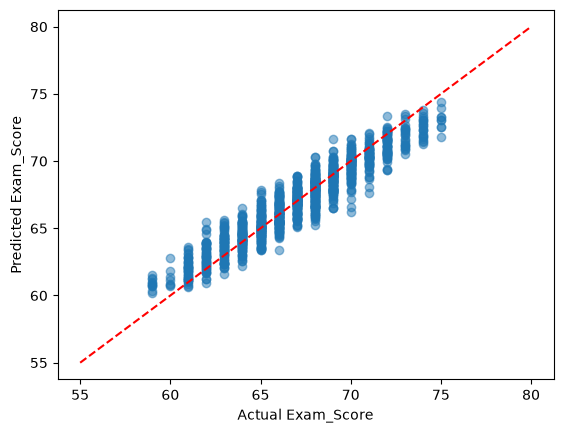

In [9]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([55, 80], [55, 80], "r--")
plt.xlabel("Actual Exam_Score")
plt.ylabel("Predicted Exam_Score")
plt.show()